# Imports and definitions

In [2]:
# imports
from matplotlib.ticker import ScalarFormatter
from kuibit.simdir import SimDir
from scipy.integrate import simpson
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numpy import sqrt
import numpy as np
import os

In [3]:
# display dynamical plots
%matplotlib widget

In [4]:
# change the directory to cactus here
CACTUS_ROOT = "/home/undercover/projects/cactus"

In [5]:
# calls Carpet2ygraphCat.pl to write a 1D quantity from ASCII to plain text, with the format
# ```
#  # time = xxx
#  coord value
#  (...)
# ```
# returns a dictionary with the list of `coord` and `value` for all instants of time
# if there are more than one `output-XXXX`, it appends to the previous timesteps
# if there are overlapping time steps, then the higher output is considered
def GetMesh(sd, quantity, axis):
    coords = {}
    data = {}

    for N in [s.replace("output-", "") for s in os.popen(f"ls {sd.path}").read().split()[1:]]:
        path = f"{sd.path}/output-{N}/{quantity}.{axis}.asc"
        xgpath = f"{sd.path}/output-{N}/{quantity}.{axis}.xg"

        if not os.path.isfile(xgpath):
            os.popen(f"perl {CACTUS_ROOT}/repos/carpet/CarpetIOASCII/src/util/Carpet2ygraphCat.pl {path}")
            os.wait()

        file = open(xgpath, "r")
        file_str = file.read()

        for block in file_str.split("\n\n#")[1:]:
            block = block.split("\n")

            time = block[0].split()[-1]

            N = len(block[1:-1])
            coords[f"t={time}"] = np.empty(N)
            data[f"t={time}"]   = np.empty(N)

            i = 0
            for line in block[1:-1]:
                line = line.split()
                coords[f"t={time}"][i] = float(line[0])
                data[f"t={time}"][i]   = float(line[1])

                i += 1

        file.close()

    return coords, data

# sextic potential

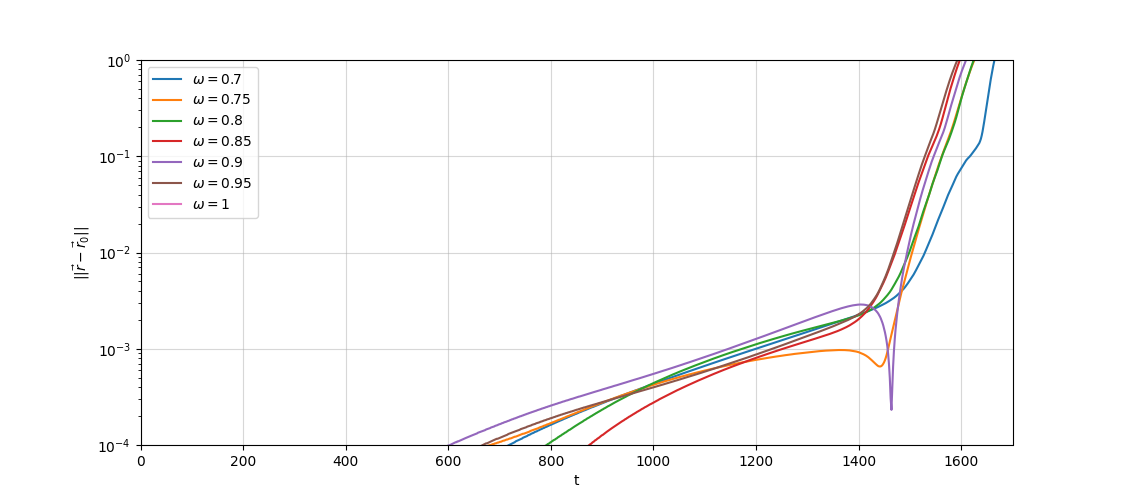

In [ ]:
rh = "0.2000"
plt.suptitle(f"$r_h = 0.2$")

simulations = [
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.700_h=4",
    f"sextic_upper_alpha=0s.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.750_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.800_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.850_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.900_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.950_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=1.000_h=4",
]

titles = [
    r"$ \omega = 0.7  $",
    r"$ \omega = 0.75 $",
    r"$ \omega = 0.8  $",
    r"$ \omega = 0.85 $",
    r"$ \omega = 0.9  $",
    r"$ \omega = 0.95 $",
    r"$ \omega = 1    $",
]

fig, ax1 = plt.subplots(1, 1, figsize=(11.25,5))

for title,simulation in zip(titles,simulations):
    try:
        sd = SimDir(f"../simulations/{simulation}")
    except:
        continue

    hor  = sd.horizons
    hor1 = hor.get_apparent_horizon(1)

    c_x = hor1.get_ah_property("centroid_x")
    c_y = hor1.get_ah_property("centroid_y")
    c_z = hor1.get_ah_property("centroid_z")

    ax1.plot(
        c_x.t,
        sqrt((c_x.values-c_x.values[0])**2+(c_y.values-c_y.values[0])**2+(c_z.values-c_z.values[0])**2),
        label=title
    )

ax1.set_ylim(bottom=1e-4, top=1e0)
ax1.set_xlim(left=0, right=1700)
ax1.set_yscale("log")
ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_ylabel(r"$||\vec{r}-\vec{r}_0||$")
ax1.legend();

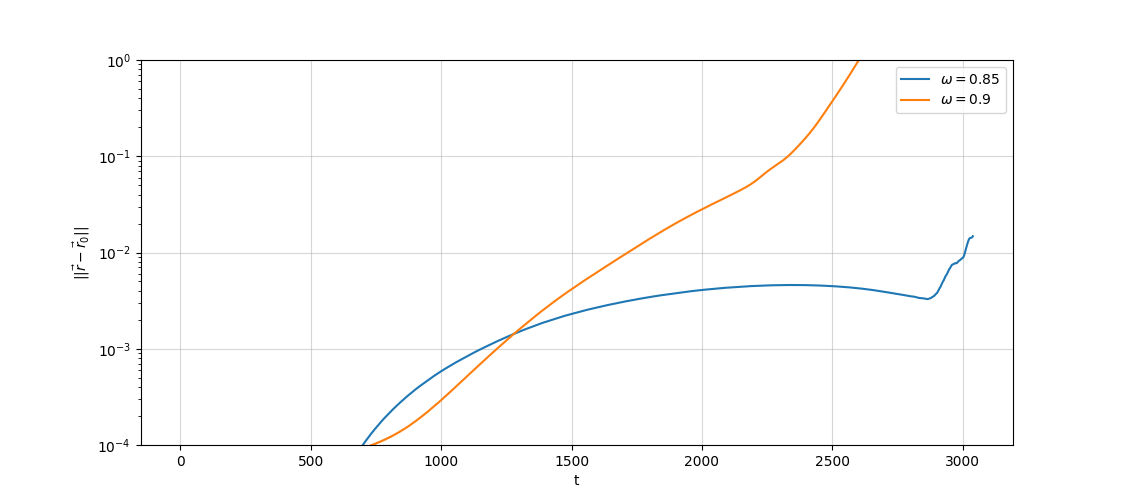

In [ ]:
rh = "0.2500"
plt.suptitle(f"$r_h = 0.25$")

simulations = [
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.700_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.750_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.800_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.850_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.900_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.950_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=1.000_h=4",
]

titles = [
    r"$ \omega = 0.7  $",
    r"$ \omega = 0.75 $",
    r"$ \omega = 0.8  $",
    r"$ \omega = 0.85 $",
    r"$ \omega = 0.9  $",
    r"$ \omega = 0.95 $",
    r"$ \omega = 1    $",
]

fig, ax1 = plt.subplots(1, 1, figsize=(11.25,5))

for title,simulation in zip(titles,simulations):
    try:
        sd = SimDir(f"../simulations/{simulation}")
    except:
        continue

    hor  = sd.horizons
    hor1 = hor.get_apparent_horizon(1)

    c_x = hor1.get_ah_property("centroid_x")
    c_y = hor1.get_ah_property("centroid_y")
    c_z = hor1.get_ah_property("centroid_z")

    ax1.plot(
        c_x.t,
        sqrt((c_x.values-c_x.values[0])**2+(c_y.values-c_y.values[0])**2+(c_z.values-c_z.values[0])**2),
        label=title
    )

ax1.set_ylim(bottom=1e-4, top=1e0)
#ax1.set_xlim(left=0, right=1700)
ax1.set_yscale("log")
ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_ylabel(r"$||\vec{r}-\vec{r}_0||$")
ax1.legend();

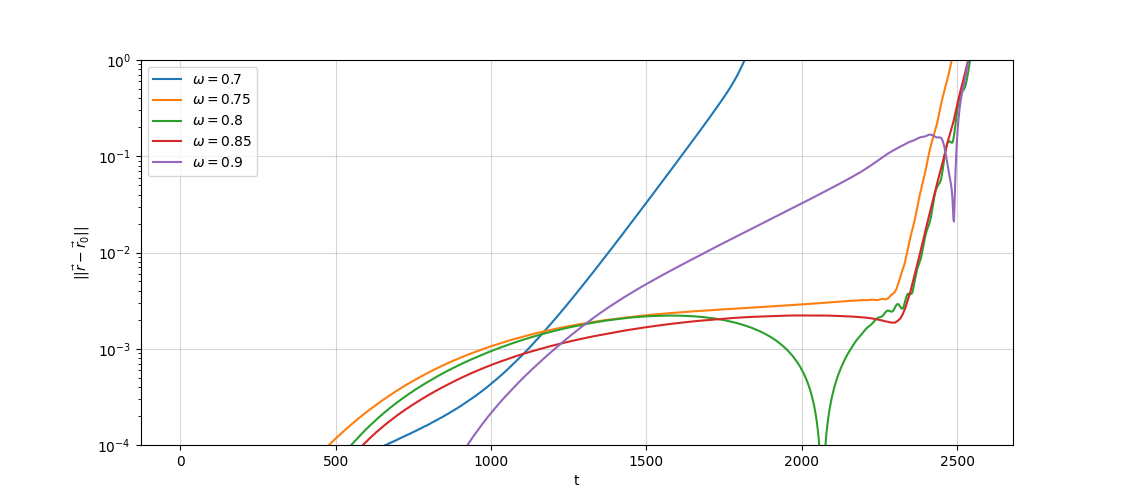

In [ ]:
rh = "0.3000"
plt.suptitle(f"$r_h = 0.3$")

simulations = [
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.700_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.750_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.800_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.850_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.900_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=0.950_h=4",
    f"sextic_upper_alpha=0.1-q=0.3385-mu=1-gamma=3.97887-rh={rh}-w=1.000_h=4",
]

titles = [
    r"$ \omega = 0.7  $",
    r"$ \omega = 0.75 $",
    r"$ \omega = 0.8  $",
    r"$ \omega = 0.85 $",
    r"$ \omega = 0.9  $",
    r"$ \omega = 0.95 $",
    r"$ \omega = 1    $",
]

fig, ax1 = plt.subplots(1, 1, figsize=(11.25,5))

for title,simulation in zip(titles,simulations):
    try:
        sd = SimDir(f"../simulations/{simulation}")
    except:
        continue

    hor  = sd.horizons
    hor1 = hor.get_apparent_horizon(1)

    c_x = hor1.get_ah_property("centroid_x")
    c_y = hor1.get_ah_property("centroid_y")
    c_z = hor1.get_ah_property("centroid_z")

    ax1.plot(
        c_x.t,
        sqrt((c_x.values-c_x.values[0])**2+(c_y.values-c_y.values[0])**2+(c_z.values-c_z.values[0])**2),
        label=title
    )

ax1.set_ylim(bottom=1e-4, top=1e0)
#ax1.set_xlim(left=0, right=1700)
ax1.set_yscale("log")
ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_ylabel(r"$||\vec{r}-\vec{r}_0||$")
ax1.legend();

# Axionic potential

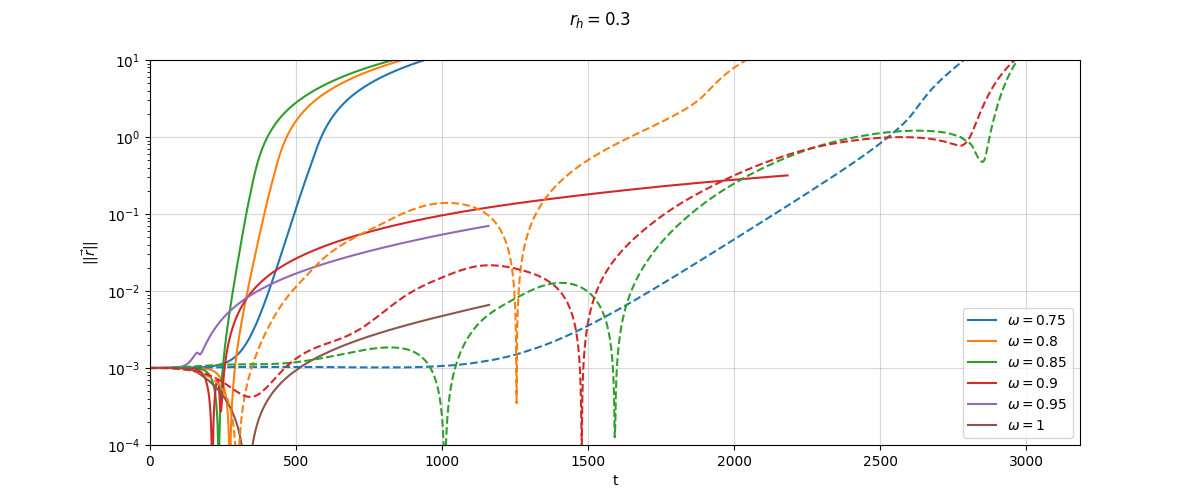

In [4]:
simulations = [
    "axionic_lower_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.750_h=5.12",
    "axionic_lower_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.800_h=5.12",
    "axionic_lower_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.850_h=5.12",
    "axionic_lower_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.900_h=5.12",
    "axionic_lower_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.950_h=5.12",
    "axionic_lower_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=1.000_h=5.12",

    "axionic_upper_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.750_h=5.12",
    "axionic_upper_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.800_h=5.12",
    "axionic_upper_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.850_h=5.12",
    "axionic_upper_alpha=1-q=3-mu=1-B=0.22-fa=0.01-rh=0.3000-w=0.900_h=5.12",
]

titles = [
    r"$\omega = 0.75$",
    r"$\omega = 0.8$",
    r"$\omega = 0.85$",
    r"$\omega = 0.9$",
    r"$\omega = 0.95$",
    r"$\omega = 1$",

    "",
    "",
    "",
    "",
]

colors = [
    "C0",
    "C1",
    "C2",
    "C3",
    "C4",
    "C5",

    "C0",
    "C1",
    "C2",
    "C3"
]

linestyles = [
    "solid",
    "solid",
    "solid",
    "solid",
    "solid",
    "solid",

    "dashed",
    "dashed",
    "dashed",
    "dashed"
]

fig, ax1 = plt.subplots(1, 1, figsize=(12,5))
plt.suptitle(r"$r_h = 0.3$")

for simulation,title,color,linestyle in zip(simulations,titles,colors,linestyles):
    sd = SimDir(f"../simulations/{simulation}")

    hor  = sd.horizons
    hor1 = hor.get_apparent_horizon(1)

    c_x = hor1.get_ah_property("centroid_x")
    c_y = hor1.get_ah_property("centroid_y")
    c_z = hor1.get_ah_property("centroid_z")

    ax1.plot(c_x.t, sqrt(c_x.values**2 + c_y.values**2 + c_z.values**2), label=title, color=color, linestyle=linestyle)

ax1.set_ylim(bottom=1e-4, top=1e1)
ax1.set_xlim(left=0)
ax1.set_yscale("log")
ax1.grid(alpha=0.5)
ax1.set_xlabel("t")
ax1.set_ylabel(r"$||\vec{r}||$")
ax1.legend();